# Explainability SHAP del CatBoost probabilistico

Questo notebook spiega il miglior modello probabilistico del notebook 02 senza riaddestrarlo.

- **globale:** calcola SHAP su tutte le righe del training e mostra bar plot e beeswarm;
- **locale:** fra i veri positivi del test sceglie l'ora con il maggiore contributo SHAP positivo complessivo della famiglia GNSS (PWV/ZWD/ZTD), quindi mostra waterfall e force plot.

Un waterfall è necessariamente locale: somma i contributi delle feature per una singola previsione. Usare la media dei contributi con segno sull'intero training sarebbe fuorviante, perché contributi positivi e negativi si cancellerebbero. Per il comportamento globale usiamo quindi la media di `|SHAP|` e il beeswarm.


In [1]:
from importlib.metadata import version
import json
from pathlib import Path

from catboost import CatBoostClassifier
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

ROOT = Path.cwd()
if not (ROOT / 'gnss_weather').exists():
    ROOT = ROOT.parent

METRICS_PATH = ROOT / 'data/derived/ml/MATE00ITA_catboost_2y_walkforward_mar_apr_metrics.json'
OUTPUT_DIR = ROOT / 'data/derived/ml/shap'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TEST_START = pd.Timestamp('2026-03-01', tz='UTC')
TEST_END_EXCLUSIVE = pd.Timestamp('2026-05-01', tz='UTC')

{'shap': version('shap'), 'catboost': version('catboost')}


{'shap': '0.52.0', 'catboost': '1.2.10'}

In [2]:
metrics = json.loads(METRICS_PATH.read_text(encoding='utf-8'))
feature_columns = metrics['feature_columns']
dataset_path = ROOT / metrics['dataset']
frame = pd.read_csv(dataset_path)
frame['epoch_utc'] = pd.to_datetime(frame['epoch_utc'], utc=True)
frame['target_window_end_utc'] = pd.to_datetime(frame['target_window_end_utc'], utc=True)
frame = frame.set_index('epoch_utc').sort_index()

training = frame.loc[frame.index < TEST_START].copy()
test = frame.loc[(frame.index >= TEST_START) & (frame.index < TEST_END_EXCLUSIVE)].copy()

model_path = ROOT / metrics['probability_model_raw']['model_path']
model = CatBoostClassifier()
model.load_model(model_path)

assert len(training) == metrics['development']['rows']
assert len(test) == metrics['test']['rows']
assert not training[feature_columns].isna().any().any()

pd.DataFrame({
    'rows': [len(training), len(test)],
    'rain_hours': [int(training.is_rain.sum()), int(test.is_rain.sum())],
    'start': [training.index.min(), test.index.min()],
    'end': [training.index.max(), test.index.max()],
}, index=['training', 'test'])


,rows,rain_hours,start,end
training,11466,1478,2024-07-01 03:00:00+00:00,2026-02-27 23:00:00+00:00
test,1407,301,2026-03-01 03:00:00+00:00,2026-04-30 23:00:00+00:00


## Caso locale: vera pioggia sostenuta dalle feature GNSS

`is_rain = 1` significa che, all'epoca delle feature, ERA5 registra pioggia nella successiva finestra oraria. Fra i veri positivi (`P(rain) >= 0.5`) scegliamo il caso con la massima somma dei contributi SHAP positivi di PWV, ZWD e ZTD. Il caso appartiene al test, non al training. È una scelta illustrativa dichiarata, non una misura del contributo GNSS medio.


In [3]:
explainer = shap.TreeExplainer(model)
test_probability = model.predict_proba(test[feature_columns])[:, 1]
rain_positions = np.flatnonzero(
    (test['is_rain'].to_numpy(dtype=int) == 1) & (test_probability >= 0.5)
)
rain_shap = explainer(test.iloc[rain_positions][feature_columns])
gnss_feature_indices = np.asarray([
    index for index, feature in enumerate(feature_columns)
    if feature.startswith(('ztd_', 'zwd_', 'pwv_'))
])
gnss_positive_shap = np.maximum(
    rain_shap.values[:, gnss_feature_indices], 0.0
).sum(axis=1)
selected_rain_offset = int(np.argmax(gnss_positive_shap))
selected_position = int(rain_positions[selected_rain_offset])
selected = test.iloc[[selected_position]]
selected_probability = float(test_probability[selected_position])
selected_epoch = selected.index[0]
selected_gnss_positive_shap = float(gnss_positive_shap[selected_rain_offset])

selected_case = pd.Series({
    'feature_epoch_utc': selected_epoch,
    'target_window_end_utc': selected['target_window_end_utc'].iloc[0],
    'rain_next_hour_mm': float(selected['rain_next_hour_mm'].iloc[0]),
    'predicted_probability': selected_probability,
    'observed_is_rain': int(selected['is_rain'].iloc[0]),
    'positive_gnss_shap_log_odds': selected_gnss_positive_shap,
    'selection': 'true positive with maximum summed positive SHAP across PWV/ZWD/ZTD features',
})
selected_case


feature_epoch_utc                                      2026-04-30 08:00:00+00:00
target_window_end_utc                                  2026-04-30 09:00:00+00:00
rain_next_hour_mm                                                            0.8
predicted_probability                                                   0.649773
observed_is_rain                                                               1
positive_gnss_shap_log_odds                                             1.584997
selection                      true positive with maximum summed positive SHA...
dtype: object

## SHAP globale su tutto il training

`TreeExplainer` calcola i contributi esatti degli alberi per tutte le righe usate nel fit finale. I valori sono nello spazio del margine raw, cioè **log-odds**, non punti percentuali di probabilità.


In [4]:
training_shap = explainer(training[feature_columns])

assert training_shap.shape == (len(training), len(feature_columns))
global_importance = pd.DataFrame({
    'feature': feature_columns,
    'mean_abs_shap_log_odds': np.abs(training_shap.values).mean(axis=0),
    'mean_shap_log_odds': training_shap.values.mean(axis=0),
}).sort_values('mean_abs_shap_log_odds', ascending=False)

global_importance.head(15)


,feature,mean_abs_shap_log_odds,mean_shap_log_odds
30,temperature_c,1.050550,0.020855
28,solar_zenith_deg,0.336419,-0.001256
25,hour_cos,0.321577,0.000995
27,doy_cos,0.296924,0.007402
29,pressure_hpa,0.275839,-0.001252
26,doy_sin,0.179860,-0.002101
1,zwd_mm,0.178328,-0.004993
13,zwd_mm_mean_1h,0.172140,0.012264
15,zwd_mm_mean_3h,0.153875,0.000256
8,pwv_mm_mean_3h,0.128452,-0.010001


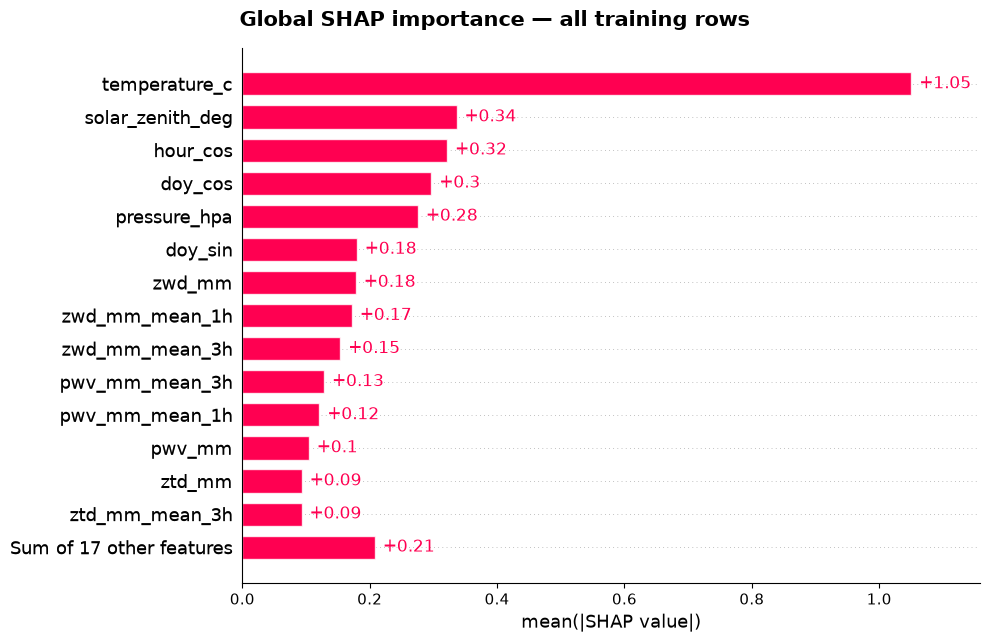

In [5]:
global_bar_path = OUTPUT_DIR / 'catboost_probability_shap_global_bar_training.png'
shap.plots.bar(training_shap, max_display=15, show=False)
figure = plt.gcf()
figure.set_size_inches(10, 6.5)
figure.suptitle('Global SHAP importance — all training rows', fontsize=15, fontweight='bold')
figure.tight_layout()
figure.savefig(global_bar_path, dpi=180, bbox_inches='tight')
plt.show()


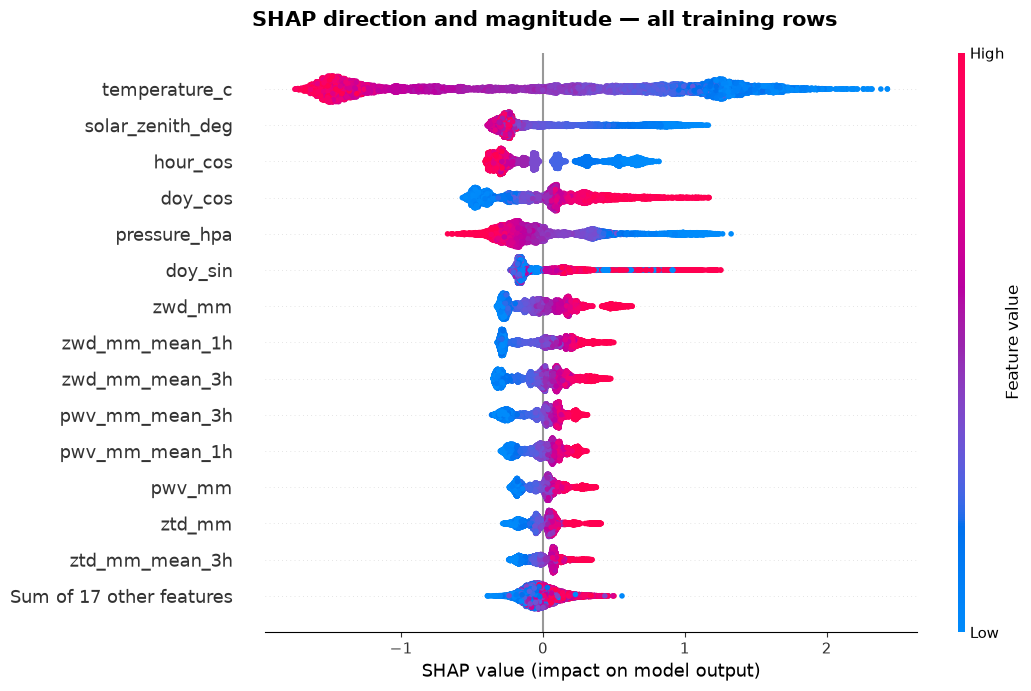

In [6]:
beeswarm_path = OUTPUT_DIR / 'catboost_probability_shap_beeswarm_training.png'
shap.plots.beeswarm(training_shap, max_display=15, show=False)
figure = plt.gcf()
figure.set_size_inches(11, 7)
figure.suptitle('SHAP direction and magnitude — all training rows', fontsize=15, fontweight='bold')
figure.tight_layout()
figure.savefig(beeswarm_path, dpi=180, bbox_inches='tight')
plt.show()


## Spiegazione locale della previsione piovosa

Il waterfall parte dal valore medio del modello e aggiunge i contributi positivi e negativi fino al margine della singola previsione. Il force plot visualizza la stessa somma in forma compatta. La probabilità riportata nel titolo è la trasformazione logistica del margine.


In [7]:
local_shap = explainer(selected[feature_columns])[0]
base_log_odds = float(np.asarray(local_shap.base_values).squeeze())
prediction_log_odds = float(base_log_odds + local_shap.values.sum())
probability_from_shap = float(1.0 / (1.0 + np.exp(-prediction_log_odds)))

assert np.isclose(probability_from_shap, selected_probability, atol=1e-10)
pd.Series({
    'base_log_odds': base_log_odds,
    'prediction_log_odds': prediction_log_odds,
    'probability_reconstructed_from_shap': probability_from_shap,
    'catboost_probability': selected_probability,
})


base_log_odds                         -2.700958
prediction_log_odds                    0.618043
probability_reconstructed_from_shap    0.649773
catboost_probability                   0.649773
dtype: float64

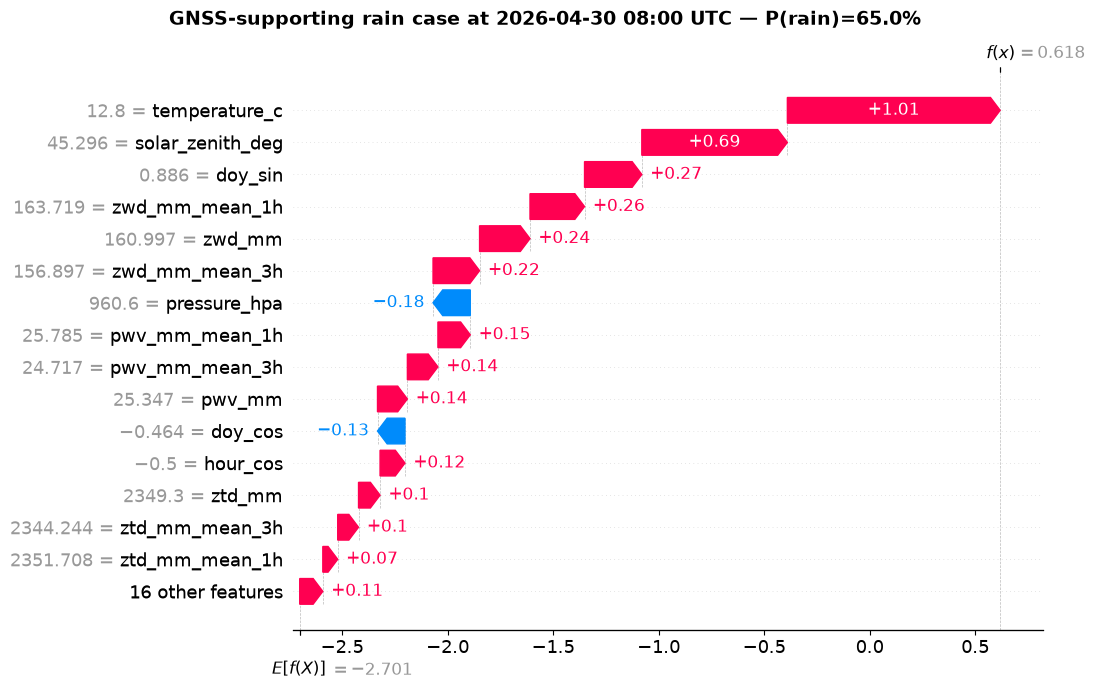

In [8]:
waterfall_path = OUTPUT_DIR / 'catboost_probability_shap_waterfall_rain_case.png'
shap.plots.waterfall(local_shap, max_display=16, show=False)
figure = plt.gcf()
figure.set_size_inches(11, 7)
figure.suptitle(
    f'GNSS-supporting rain case at {selected_epoch:%Y-%m-%d %H:%M UTC} — P(rain)={selected_probability:.1%}',
    fontsize=14, fontweight='bold',
)
figure.tight_layout()
figure.savefig(waterfall_path, dpi=180, bbox_inches='tight')
plt.show()


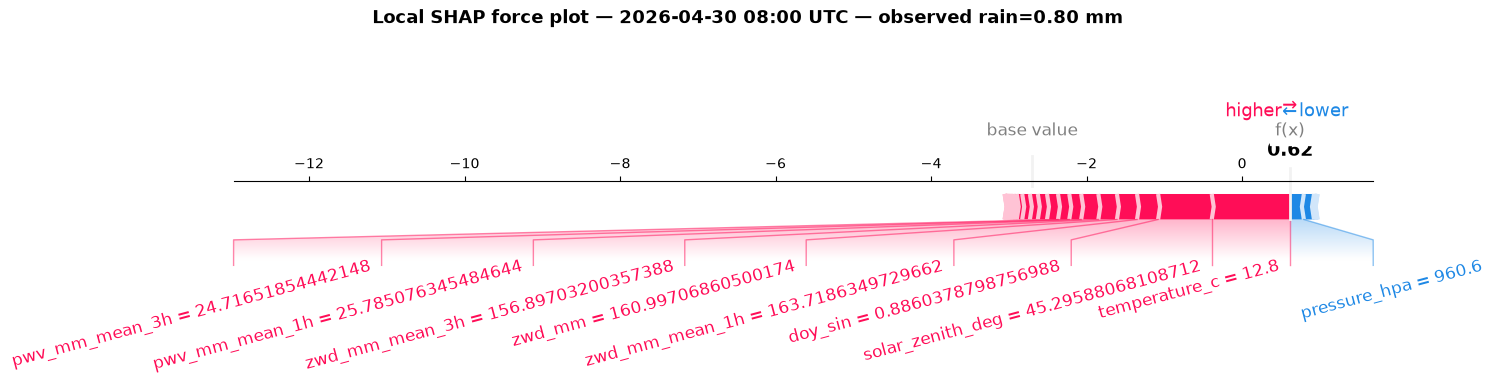

In [9]:
force_path = OUTPUT_DIR / 'catboost_probability_shap_force_rain_case.png'
force_html_path = OUTPUT_DIR / 'catboost_probability_shap_force_rain_case.html'
force_figure = shap.force_plot(
    base_value=base_log_odds,
    shap_values=local_shap.values,
    features=selected[feature_columns].iloc[0],
    feature_names=feature_columns,
    link='identity',  # static renderer: native CatBoost log-odds
    matplotlib=True,
    show=False,
    figsize=(15, 3.6),
    text_rotation=15,
)
force_figure.suptitle(
    f'Local SHAP force plot — {selected_epoch:%Y-%m-%d %H:%M UTC} — observed rain={selected_case["rain_next_hour_mm"]:.2f} mm',
    fontsize=13, fontweight='bold',
)
force_figure.tight_layout()
force_figure.savefig(force_path, dpi=180, bbox_inches='tight')
display(force_figure)
plt.close(force_figure)

interactive_force = shap.force_plot(
    base_value=base_log_odds,
    shap_values=local_shap.values,
    features=selected[feature_columns].iloc[0],
    feature_names=feature_columns,
    link='logit',
)
shap.save_html(str(force_html_path), interactive_force)


In [10]:
importance_path = OUTPUT_DIR / 'catboost_probability_shap_global_importance_training.csv'
state_path = OUTPUT_DIR / 'catboost_probability_shap_training_values.npz'
case_path = OUTPUT_DIR / 'catboost_probability_shap_rain_case.json'

global_importance.to_csv(importance_path, index=False)
np.savez_compressed(
    state_path,
    values=training_shap.values,
    base_values=training_shap.base_values,
    feature_names=np.asarray(feature_columns),
    epoch_utc=training.index.tz_convert('UTC').tz_localize(None).to_numpy(dtype='datetime64[ns]'),
)
case_path.write_text(json.dumps({
    'feature_epoch_utc': selected_epoch.isoformat(),
    'target_window_end_utc': selected['target_window_end_utc'].iloc[0].isoformat(),
    'rain_next_hour_mm': float(selected['rain_next_hour_mm'].iloc[0]),
    'predicted_probability': selected_probability,
    'base_log_odds': base_log_odds,
    'prediction_log_odds': prediction_log_odds,
    'positive_gnss_shap_log_odds': selected_gnss_positive_shap,
    'selection': 'true positive with maximum summed positive SHAP across PWV/ZWD/ZTD features',
    'top_contributions': [
        {
            'feature': feature_columns[index],
            'feature_value': float(selected[feature_columns].iloc[0, index]),
            'shap_log_odds': float(local_shap.values[index]),
        }
        for index in np.argsort(np.abs(local_shap.values))[::-1][:15]
    ],
}, indent=2) + '\n', encoding='utf-8')

global_bar_path, beeswarm_path, waterfall_path, force_path, force_html_path, importance_path, state_path, case_path


(WindowsPath('C:/Users/vince/repos/gnss-weather/data/derived/ml/shap/catboost_probability_shap_global_bar_training.png'),
 WindowsPath('C:/Users/vince/repos/gnss-weather/data/derived/ml/shap/catboost_probability_shap_beeswarm_training.png'),
 WindowsPath('C:/Users/vince/repos/gnss-weather/data/derived/ml/shap/catboost_probability_shap_waterfall_rain_case.png'),
 WindowsPath('C:/Users/vince/repos/gnss-weather/data/derived/ml/shap/catboost_probability_shap_force_rain_case.png'),
 WindowsPath('C:/Users/vince/repos/gnss-weather/data/derived/ml/shap/catboost_probability_shap_force_rain_case.html'),
 WindowsPath('C:/Users/vince/repos/gnss-weather/data/derived/ml/shap/catboost_probability_shap_global_importance_training.csv'),
 WindowsPath('C:/Users/vince/repos/gnss-weather/data/derived/ml/shap/catboost_probability_shap_training_values.npz'),
 WindowsPath('C:/Users/vince/repos/gnss-weather/data/derived/ml/shap/catboost_probability_shap_rain_case.json'))

## Limiti dell'interpretazione

- SHAP descrive il comportamento del modello, non dimostra causalità atmosferica.
- PWV, ZWD e ZTD sono fortemente correlate: il modello e SHAP possono distribuire lo stesso segnale fra feature diverse.
- Il force plot spiega una previsione ben riuscita scelta intenzionalmente; per valutare robustezza servono anche falsi positivi, falsi negativi e casi a bassa confidenza.
- I contributi locali sono additivi in log-odds. Il loro effetto in probabilità non è lineare.
